# DeepSeek-Foundations · Workbook 03

### Probability & Statistics — models as distributions, Bayes, and maximum likelihood

**Series:** DeepSeek-Foundations v1.0 · **Runtime:** ~75 min · **Prereqs:** high-school probability

---

> **Abstract.** An LLM is not a rule-based text engine; it is a machine for estimating probability distributions over tokens. This workbook builds the probabilistic toolkit that makes that statement precise. We define random variables and their distributions, expectation and variance, and the joint/marginal/conditional machinery whose chain rule is the reason autoregressive language models factor text left-to-right. We derive Bayes' theorem and work a full medical-test example that exposes how priors dominate posteriors, then show that maximum likelihood estimation — "find the parameters that make the observed data most probable" — is exactly the objective minimized when an LLM is trained. The final section turns the categorical distribution and the softmax into the output layer of a real model, with temperature as a dial on sample diversity. Every section ends in executable NumPy: a distribution you can sample from is a distribution you understand.

**How this fits the series:** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb) states the central claim — an LLM is a differentiable map from token sequences to next-token distributions. Workbook 02 supplied the *differentiable* part (gradients); this workbook supplies the *distribution* part. [Workbook 04 — Information Theory](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/04_Information_Theory.ipynb) then turns the log-likelihood you will meet in Section 5 into entropy, cross-entropy, and perplexity — the actual loss printed in every LLM training run.


## 1. Random variables and distributions

A **sample space** $\Omega$ is the set of all possible outcomes of an experiment; an **event** is a subset of $\Omega$. A **probability measure** assigns each event a number in $[0, 1]$ such that $P(\Omega) = 1$ and probabilities add over disjoint events. A **random variable** $X$ is a function $X: \Omega \to \mathbb{R}$ — a way of turning outcomes into numbers we can do arithmetic on.

- **Discrete** $X$ takes countably many values and is described by its **probability mass function** (PMF) $p(x) = P(X = x)$, with $\sum_x p(x) = 1$. The workhorse example is the **Bernoulli** distribution, $X \in \{0, 1\}$ with $P(X = 1) = p$: a single coin flip, and also the unit out of which every binarized decision is built.
- **Continuous** $X$ is described by its **probability density function** (PDF) $f(x) \ge 0$ with $\int_{-\infty}^{\infty} f(x)\, dx = 1$; probabilities are integrals $P(a < X < b) = \int_a^b f(x)\, dx$. The workhorse is the **Gaussian** (normal) distribution

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}}\, \exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right), \qquad X \sim \mathcal{N}(\mu, \sigma^2),$$

whose two parameters $\mu$ (location) and $\sigma^2$ (spread) explain why "normal" noise appears everywhere from measurement error to the central limit theorem.

**Why an LLM cares.** Every token position is a random variable; a text is a realization of a *sequence* of them. The model never outputs "the next word" — it outputs a distribution over the vocabulary (a PMF with $|\mathcal{V}|$ outcomes). Sampling from that PMF is how text gets written.

Bernoulli PMF  P(X=x): {np.int64(0): np.float64(0.3), np.int64(1): np.float64(0.7)}
quantile  empirical   theoretical (mu + sigma * z)
    5%      -2.284       -2.290
   25%      -0.349       -0.349
   50%      +0.995       +1.000
   75%      +2.360       +2.349
   95%      +4.274       +4.290


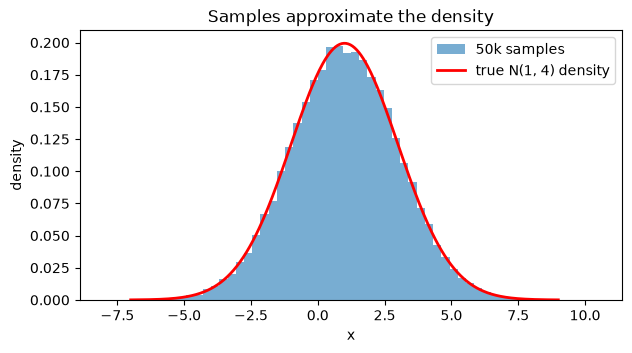

In [1]:

import numpy as np
import matplotlib.pyplot as plt

# Bernoulli PMF: one parameter p is a whole distribution
p = 0.7
x = np.array([0, 1])
pmf = np.array([1 - p, p])
print("Bernoulli PMF  P(X=x):", dict(zip(x, pmf.round(3))))

# Gaussian PDF: 50k samples vs the true density they were drawn from
rng = np.random.default_rng(0)
mu, sigma = 1.0, 2.0
samples = rng.normal(mu, sigma, size=50_000)

# Empirical quantiles vs textbook standard-normal quantiles (z-scores)
qs = np.array([0.05, 0.25, 0.50, 0.75, 0.95])
z = np.array([-1.6449, -0.6745, 0.0, 0.6745, 1.6449])
print("quantile  empirical   theoretical (mu + sigma * z)")
for q, e, t in zip(qs, np.quantile(samples, qs), mu + sigma * z):
    print(f"  {q:4.0%}     {e:+7.3f}      {t:+7.3f}")

# Histogram of samples against the true density curve
grid = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 400)
pdf = np.exp(-0.5 * ((grid - mu) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))
plt.figure(figsize=(7, 3.5))
plt.hist(samples, bins=60, density=True, alpha=0.6, label="50k samples")
plt.plot(grid, pdf, "r-", lw=2, label="true N(1, 4) density")
plt.xlabel("x"); plt.ylabel("density"); plt.legend(); plt.title("Samples approximate the density")
plt.show()


## 2. Expectation and variance

The **expectation** is the probability-weighted average:

$$\mathbb{E}[X] = \sum_x x\, p(x) \quad \text{(discrete)}, \qquad \mathbb{E}[X] = \int x\, f(x)\, dx \quad \text{(continuous)}.$$

The single most useful fact in this workbook is **linearity of expectation**: for any constants $a, b$ and any two random variables $X, Y$ — dependent or not —

$$\mathbb{E}[aX + bY] = a\,\mathbb{E}[X] + b\,\mathbb{E}[Y].$$

No independence is required: expectation is a sum, and sums commute. The **variance** measures spread,

$$\mathrm{Var}[X] = \mathbb{E}\big[(X - \mathbb{E}[X])^2\big] = \mathbb{E}[X^2] - \mathbb{E}[X]^2,$$

with standard deviation $\sigma_X = \sqrt{\mathrm{Var}[X]}$ in the same units as $X$. The **law of large numbers** says the sample mean of i.i.d. draws converges to the expectation: $\frac{1}{N}\sum_{i=1}^N X_i \to \mathbb{E}[X]$ as $N \to \infty$.

**Why an LLM cares.** The training loss is an expectation over the data distribution. Gradient descent never sees the true expectation — a minibatch is a Monte Carlo estimate of it, and SGD is exactly "stochastic" because of that. Workbook 05 builds on this.

In [2]:

import numpy as np
rng = np.random.default_rng(7)

# Fair die: E[X] = 3.5, Var[X] = (6^2 - 1) / 12 = 35/12 = 2.9167
rolls = rng.integers(1, 7, size=100_000)
print(f"die:  empirical mean {rolls.mean():.4f}   (theoretical 3.5000)")
print(f"      empirical var  {rolls.var():.4f}   (theoretical 2.9167)")

# Law of large numbers: the running mean tightens around 3.5
for n in (10, 100, 1_000, 10_000, 100_000):
    print(f"      mean of first {n:6d} rolls: {rolls[:n].mean():.4f}")

# Gaussian: empirical vs theoretical moments
mu, sigma = -2.0, 3.0
g = rng.normal(mu, sigma, size=100_000)
print(f"gauss: empirical mean {g.mean():+.4f}  var {g.var():.4f}   (theoretical {mu}, {sigma**2})")

# Linearity of expectation holds even for dependent variables: y = 2x + noise
x = rng.normal(0, 1, 100_000)
y = 2 * x + rng.normal(0, 1, 100_000)
print(f"E[X+Y]: empirical {(x + y).mean():+.4f}  vs  E[X]+E[Y] = {x.mean():+.4f} + {y.mean():+.4f}")


die:  empirical mean 3.5071   (theoretical 3.5000)
      empirical var  2.9235   (theoretical 2.9167)
      mean of first     10 rolls: 4.1000
      mean of first    100 rolls: 3.6900
      mean of first   1000 rolls: 3.5750
      mean of first  10000 rolls: 3.4966
      mean of first 100000 rolls: 3.5071
gauss: empirical mean -1.9923  var 9.0171   (theoretical -2.0, 9.0)
E[X+Y]: empirical +0.0058  vs  E[X]+E[Y] = +0.0025 + +0.0033


## 3. Joint, marginal, conditional — why LLMs read left to right

For two random variables the **joint distribution** $P(X = x, Y = y)$ describes them together. From it we recover:

- **Marginal:** $P(X = x) = \sum_y P(x, y)$ — sum over the other variable (the "total probability" of $x$).
- **Conditional:** $P(Y = y \mid X = x) = \dfrac{P(x, y)}{P(x)}$ — renormalize the joint to a fixed $x$. This is also how the joint factorizes: $P(x, y) = P(x)\, P(y \mid x)$.

Repeated application gives the **chain rule of probability** — the single most important equation in this workbook:

$$p(x_1, x_2, \dots, x_n) = \prod_{t=1}^{n} p(x_t \mid x_1, \dots, x_{t-1}) = \prod_{t=1}^{n} p(x_t \mid x_{<t}).$$

**Why an LLM cares.** The chain rule is an *identity*: *any* joint distribution over a token sequence factors exactly into per-token conditional probabilities. An autoregressive LLM is precisely a machine that parametrizes each factor $p_\theta(x_t \mid x_{<t})$ — usually with a transformer — and then multiplies them. "Next-token prediction" is therefore not a simplification of language modeling; it is language modeling, verbatim, left to right.

In [3]:

import numpy as np

# Joint distribution P(A, B) over two 3-valued variables: rows = A, cols = B
joint = np.array([
    [0.10, 0.05, 0.05],
    [0.08, 0.20, 0.02],
    [0.02, 0.03, 0.45],
])
print("joint sums to 1:", np.isclose(joint.sum(), 1.0))

pA = joint.sum(axis=1)                     # marginal P(A): sum over B
pB = joint.sum(axis=0)                     # marginal P(B): sum over A
print("marginal P(A):", pA.round(3))
print("marginal P(B):", pB.round(3))

pB_given_A = joint / pA[:, None]           # conditional P(B | A), renormalized rows
print("rows of P(B|A) sum to 1:", pB_given_A.sum(axis=1).round(6))
print("P(A=0, B=1) via chain rule:", (pA[0] * pB_given_A[0, 1]).round(4), " (joint says", joint[0, 1], ")")

# Chain rule on a 3-variable toy: build P(A,B,C) from the three factors p(a) p(b|a) p(c|a,b)
pA3 = np.array([0.3, 0.5, 0.2])                                    # P(A)
pB_given_A3 = np.array([[0.6, 0.3, 0.1],                           # P(B | A)
                        [0.2, 0.5, 0.3],
                        [0.1, 0.2, 0.7]])
pC_given_AB = np.zeros((3, 3, 3))                                  # P(C | A, B)
for a in range(3):
    for b in range(3):
        row = np.array([0.7, 0.2, 0.1]) if (a + b) % 2 == 0 else np.array([0.2, 0.3, 0.5])
        pC_given_AB[a, b] = row / row.sum()

joint3 = pA3[:, None, None] * pB_given_A3[:, :, None] * pC_given_AB   # the chain rule, in NumPy
print("P(A,B,C) built from factors sums to 1:", round(joint3.sum(), 12))

# Recover a factor from the joint — exactly what an LLM must estimate from data
pAB = joint3.sum(axis=2)                                             # P(A, B)
recon = joint3 / pAB[:, :, None]                                     # P(C | A, B) recovered
print("recovered P(C|A,B) matches the definition:",
      np.allclose(recon, pC_given_AB, atol=1e-12))

# An LLM assigns probability to text by multiplying next-token probabilities
p_I, p_love_given_I, p_math_given_Ilove = 0.01, 0.05, 0.20
print(f"P('I love math') = {p_I * p_love_given_I * p_math_given_Ilove:.6f} "
      f"(the product of three next-token conditionals)")


joint sums to 1: True
marginal P(A): [0.2 0.3 0.5]
marginal P(B): [0.2  0.28 0.52]
rows of P(B|A) sum to 1: [1. 1. 1.]
P(A=0, B=1) via chain rule: 0.05  (joint says 0.05 )
P(A,B,C) built from factors sums to 1: 1.0
recovered P(C|A,B) matches the definition: True
P('I love math') = 0.000100 (the product of three next-token conditionals)


## 4. Bayes' theorem

Bayes' theorem is the chain rule solved for the conditional in the other direction:

$$p(\theta \mid D) = \frac{p(D \mid \theta)\; p(\theta)}{p(D)} \;\propto\; \underbrace{p(D \mid \theta)}_{\text{likelihood}} \cdot \underbrace{p(\theta)}_{\text{prior}}.$$

The **prior** $p(\theta)$ encodes what we believed before seeing data; the **likelihood** $p(D \mid \theta)$ is the probability the data would have under candidate $\theta$; the **posterior** $p(\theta \mid D)$ is the updated belief. The denominator $p(D) = \int p(D \mid \theta)\, p(\theta)\, d\theta$ is just the normalizing constant — which is why the proportionality form does almost all the work.

**Why an LLM cares.** Three ways this equation runs modern ML:

1. **Posteriors over parameters:** training is a search for $\theta$ with high posterior mass; the MAP estimate $\arg\max_\theta \log p(D\mid\theta) + \log p(\theta)$ is MLE plus a log-prior — and an L2 prior is exactly weight decay.
2. **Calibration:** a model's output probabilities should match observed frequencies ("90% confident" should be right 90% of the time); Bayes' theorem is the reference frame for auditing that.
3. **Alignment:** RLHF optimizes a posterior over policies — a preference likelihood times a prior that penalizes drift from the supervised model.

The demo below shows the classic trap: with a rare disease, even an excellent test produces mostly false positives. The prior is not a nuisance — it dominates.

In [4]:

import numpy as np

# Medical test: prevalence 1%, sensitivity 99%, specificity 95%
prevalence = 0.01          # P(disease)
sens = 0.99                # P(+ | disease)
spec = 0.95                # P(- | healthy), so P(+ | healthy) = 1 - spec = 0.05

p_pos = sens * prevalence + (1 - spec) * (1 - prevalence)    # law of total probability
p_disease_given_pos = sens * prevalence / p_pos              # Bayes' theorem
print(f"P(+)           = {p_pos:.4f}   (only {p_pos:.1%} of people test positive)")
print(f"P(disease | +) = {p_disease_given_pos:.4f}   (~{p_disease_given_pos:.1%})")
print("With a 1% base rate most positives are false positives: the 99% sensitivity")
print("is swamped by the 5% false-positive rate acting on the 99% healthy majority.")

# Same test, different priors: the base rate reshapes the posterior
for base in (0.01, 0.05, 0.10, 0.50):
    pp = sens * base + (1 - spec) * (1 - base)
    print(f"  base rate {base:4.0%} -> P(disease | +) = {sens * base / pp:.3f}")

# Bayes in ML: posterior ~ likelihood * prior (up to the evidence constant)
#   p(theta | D)  proportional to  p(D | theta) * p(theta)
# Taking logs: log posterior = log likelihood + log prior.
# Maximizing that (MAP) is MLE with a regularizer -- L2 prior == weight decay.


P(+)           = 0.0594   (only 5.9% of people test positive)
P(disease | +) = 0.1667   (~16.7%)
With a 1% base rate most positives are false positives: the 99% sensitivity
is swamped by the 5% false-positive rate acting on the 99% healthy majority.
  base rate   1% -> P(disease | +) = 0.167
  base rate   5% -> P(disease | +) = 0.510
  base rate  10% -> P(disease | +) = 0.687
  base rate  50% -> P(disease | +) = 0.952


## 5. Maximum likelihood estimation — the training objective in disguise

We observe i.i.d. data $D = \{x_1, \dots, x_N\}$ drawn from some unknown distribution, and we posit a family $p(x \mid \theta)$. **Maximum likelihood estimation** picks the parameters that make the data most probable:

$$\hat\theta_{\mathrm{MLE}} = \arg\max_\theta \prod_{i=1}^N p(x_i \mid \theta) = \arg\max_\theta \sum_{i=1}^N \log p(x_i \mid \theta),$$

where the log is monotone and turns the product into a sum (numerically stable, and it becomes the loss). For a Bernoulli with parameter $p$,

$$\hat p_{\mathrm{MLE}} = \frac{1}{N}\sum_{i=1}^N x_i,$$

the empirical frequency of heads — the grid search below will land on exactly this. For a Gaussian,

$$\hat\mu_{\mathrm{MLE}} = \frac{1}{N}\sum_i x_i, \qquad \hat\sigma^2_{\mathrm{MLE}} = \frac{1}{N}\sum_i (x_i - \hat\mu)^2.$$

**Why an LLM cares.** Language modeling *is* MLE. The training objective — minimize negative log-likelihood of the next token over the corpus — is literally $\arg\max_\theta \prod_{\text{tokens}} p_\theta(x_{t+1} \mid x_{<t})$. The negative log-likelihood is what Workbook 04 will call **cross-entropy**, and gradient descent on it is how every LLM is trained.

flips: 300, heads: 110  ->  empirical frequency 0.3667
MLE (argmax of log-likelihood): 0.3700   (true p = 0.35)
Maximizing the likelihood == minimizing -log-likelihood == cross-entropy (Workbook 04).


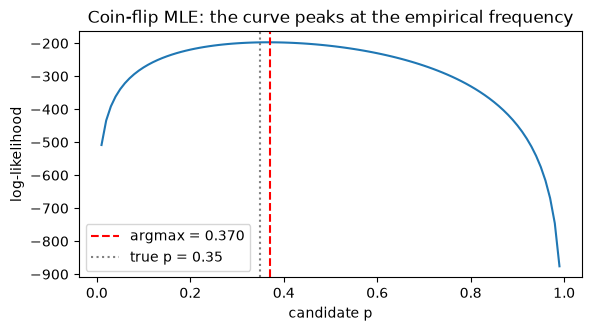

In [5]:

import numpy as np
import matplotlib.pyplot as plt

# Coin with true p = 0.35; we only see flips and must estimate p back
rng = np.random.default_rng(11)
p_true = 0.35
N = 300
flips = (rng.random(N) < p_true).astype(int)
k = flips.sum()

grid = np.linspace(0.01, 0.99, 99)
ll = k * np.log(grid) + (N - k) * np.log1p(-grid)      # log-likelihood, vectorized
p_hat = grid[np.argmax(ll)]

print(f"flips: {N}, heads: {k}  ->  empirical frequency {k / N:.4f}")
print(f"MLE (argmax of log-likelihood): {p_hat:.4f}   (true p = {p_true})")
print("Maximizing the likelihood == minimizing -log-likelihood == cross-entropy (Workbook 04).")

plt.figure(figsize=(6.5, 3.2))
plt.plot(grid, ll)
plt.axvline(p_hat, color="red", ls="--", label=f"argmax = {p_hat:.3f}")
plt.axvline(p_true, color="gray", ls=":", label=f"true p = {p_true}")
plt.xlabel("candidate p"); plt.ylabel("log-likelihood"); plt.legend()
plt.title("Coin-flip MLE: the curve peaks at the empirical frequency")
plt.show()


In [6]:

import numpy as np

# Gaussian MLE: mu_hat = sample mean, sigma2_hat = mean squared deviation (divides by N)
rng = np.random.default_rng(12)
mu_true, sigma_true = 1.5, 2.0
N = 500
x = rng.normal(mu_true, sigma_true, size=N)

mu_hat = x.mean()
sigma2_hat = ((x - mu_hat) ** 2).mean()                      # MLE estimator (1/N)
sigma2_unbiased = ((x - mu_hat) ** 2).sum() / (N - 1)        # Bessel's correction

print(f"true:        mu = {mu_true},  sigma^2 = {sigma_true**2}")
print(f"MLE:         mu = {mu_hat:.4f},  sigma^2 = {sigma2_hat:.4f}")
print(f"unbiased:    sigma^2 = {sigma2_unbiased:.4f}")
print("The MLE variance is biased slightly low for finite N; dividing by N-1 fixes it.")
print("LLM training is the same fit at scale: gradient descent on -log p(data | theta).")


true:        mu = 1.5,  sigma^2 = 4.0
MLE:         mu = 1.5273,  sigma^2 = 3.8125
unbiased:    sigma^2 = 3.8202
The MLE variance is biased slightly low for finite N; dividing by N-1 fixes it.
LLM training is the same fit at scale: gradient descent on -log p(data | theta).


## 6. The categorical distribution and softmax — the LLM output layer

The **categorical distribution** generalizes the Bernoulli to $K$ outcomes: $P(X = k) = p_k$ with $p_k \ge 0$, $\sum_k p_k = 1$. The vocabulary of an LLM is a categorical distribution over $|\mathcal{V}|$ tokens — that is the entire output layer.

A neural net produces unnormalized scores called **logits** $z \in \mathbb{R}^K$. The **softmax** turns them into a valid distribution:

$$\mathrm{softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}},$$

which is shift-invariant (adding a constant to all logits changes nothing) and strictly increasing in each logit. Add a **temperature** $T > 0$:

$$p_i = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}.$$

As $T \to 0$ the distribution collapses onto the argmax (greedy decoding); as $T \to \infty$ it flattens toward uniform (maximal diversity). Temperature, top-$k$, and top-$p$ sampling are all dials on this one distribution — "creativity" in an LLM is just how far from the argmax you allow the sampler to wander.

In [7]:

import numpy as np

# Logits from the last layer of a small "model" over a 5-token vocabulary
logits = np.array([3.0, 2.2, 1.0, 0.5, 0.1])

def softmax(z):
    e = np.exp(z - z.max())        # shift for stability; softmax is shift-invariant
    return e / e.sum()

def H(p):                          # entropy in nats; Workbook 04's star object
    p = p[p > 0]
    return -(p * np.log(p)).sum()

rng = np.random.default_rng(13)
probs = softmax(logits)
print("softmax(logits):", probs.round(4), " sum:", round(probs.sum(), 6))

for T in (0.5, 1.0, 2.0):
    pT = softmax(logits / T)
    samples = rng.choice(5, size=20_000, p=pT)
    freq = np.bincount(samples, minlength=5) / 20_000
    print(f"T = {T}: p = {pT.round(3)}, H = {H(pT):.3f} nats, empirical frequencies: {freq.round(3)}")

print("T < 1 sharpens toward the argmax (greedy); T > 1 flattens toward uniform (more")
print("diverse sampling, more mistakes). The empirical frequencies track p_T at every T.")


softmax(logits): [0.5808 0.261  0.0786 0.0477 0.032 ]  sum: 1.0
T = 0.5: p = [0.813 0.164 0.015 0.005 0.002], H = 0.571 nats, empirical frequencies: [0.812 0.165 0.015 0.005 0.002]
T = 1.0: p = [0.581 0.261 0.079 0.048 0.032], H = 1.121 nats, empirical frequencies: [0.578 0.263 0.078 0.048 0.032]
T = 2.0: p = [0.391 0.262 0.144 0.112 0.092], H = 1.461 nats, empirical frequencies: [0.392 0.262 0.144 0.109 0.094]
T < 1 sharpens toward the argmax (greedy); T > 1 flattens toward uniform (more
diverse sampling, more mistakes). The empirical frequencies track p_T at every T.


## 7. Exercises

**E1 — Expectation of a loaded die.** A die has $P(X = k) \propto k$ for $k = 1, \dots, 6$ (six is six times as likely as one). Compute $\mathbb{E}[X]$ — by hand or in NumPy — and then state $\mathbb{E}[X + Y]$ where $Y$ is an independent copy. *Hint: normalize the PMF first; expectation is a weighted average, and linearity needs no independence.*

**E2 — Chain rule by broadcasting.** Let $P(A) = [0.4, 0.6]$ and $P(B \mid A) = \begin{bmatrix} 0.8 & 0.2 \\ 0.3 & 0.7 \end{bmatrix}$. Build $P(A, B) = P(A)\, P(B \mid A)$ with NumPy broadcasting, verify that the rows of $P(B \mid A)$ sum to 1, and recover both marginals from the joint. *Hint: pA[:, None] * pB_given_A.*

**E3 — Two tests.** A disease has prevalence 1%. Test 1 has sensitivity 99% and specificity 99%; test 2 has sensitivity 99% and specificity 90%. Compute $P(\text{disease} \mid +)$ for each. *Hint: Bayes; the false-positive rate $1 - \text{spec}$ acts on the 99% healthy majority.*

**E4 — MLE sample size.** Draw $N = 50$ flips from a Bernoulli with $p = 0.6$ and find the MLE by grid search. Repeat with $N = 5000$. Which estimate is closer to 0.6, and by roughly what factor? *Hint: the standard deviation of $\hat p$ scales like $\sqrt{p(1-p)/N}$.*

**E5 — Temperature.** For logits $[2, 1, 0]$, find the smallest temperature $T$ such that no token has probability above 0.4. *Hint: search a geometric grid of $T$ values and watch the distribution flatten; the answer is not far above 5.*

## Solutions

**S1.** $P(X = k) = k / 21$ since $1 + 2 + \cdots + 6 = 21$. Then $\mathbb{E}[X] = \frac{1}{21}(1^2 + 2^2 + \cdots + 6^2) = \frac{91}{21} \approx 4.333$. By linearity $\mathbb{E}[X + Y] = 2 \times 4.333 \approx 8.667$ — no independence needed.

```python
import numpy as np
k = np.arange(1, 7)
pmf = k / k.sum()
print(pmf, (k * pmf).sum())        # [0.048 0.095 0.143 0.19 0.238 0.286] 4.333
```

**S2.** `joint = pA[:, None] * pB_given_A` gives $\begin{bmatrix} 0.32 & 0.08 \\ 0.18 & 0.42 \end{bmatrix}$; each row of the conditional sums to 1 by construction, and the marginals come back as `joint.sum(1)` and `joint.sum(0)`.

```python
import numpy as np
pA = np.array([0.4, 0.6]); pB_given_A = np.array([[0.8, 0.2], [0.3, 0.7]])
joint = pA[:, None] * pB_given_A
print(joint, joint.sum(axis=1), joint.sum(axis=0))   # P(A), P(B) recovered
```

**S3.** $P(D \mid +) = \frac{0.99 \cdot 0.01}{0.99 \cdot 0.01 + (1-\text{spec}) \cdot 0.99}$. Test 1: $0.0099 / 0.0198 = 0.5$ — a positive result is a coin flip. Test 2: $0.0099 / 0.1089 \approx 0.091$. Specificity buys more than sensitivity when the base rate is low — the same asymmetry that makes calibration audits of rare-event predictions unforgiving.

**S4.** Both grid searches land on the empirical frequency $\hat p = k/N$ (that is the point of Section 5). The $N = 5000$ estimate is about $\sqrt{5000/50} = 10\times$ tighter: $\mathrm{sd}(\hat p) \approx \sqrt{0.24/5000} \approx 0.007$ vs $\sqrt{0.24/50} \approx 0.069$. More data shrinks estimator variance at rate $1/\sqrt{N}$ — the law of large numbers, again.

**S5.** $T \approx 5.15$ is the threshold; $T = 5.2$ gives $\mathrm{softmax}([0.385, 0.192, 0]) \approx [0.399, 0.329, 0.272]$, max just under 0.4. At $T = 1$ the max probability is 0.665; at $T \to \infty$ the distribution becomes exactly uniform. This is the dial that separates "confident" generations from "exploratory" ones.

---
**Next →** [Workbook 04 — Information Theory](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/04_Information_Theory.ipynb) — entropy, cross-entropy, KL divergence, and perplexity: the loss function itself.

**← Back to** [The Master Report](https://colab.research.google.com/github/mattdani21/ml-math-foundations/blob/main/notebooks/00_DeepSeek_Foundations.ipynb) — the central claim and the full curriculum map.
